В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням kNearestNeighboors, знайдемо оптимальні гіперпараметри для цього методу і зробимо базові ансамблі. Це дасть змогу порівняти перформанс моделі з попередніми вивченими методами.

0. Зчитайте дані `train.csv` та зробіть препроцесинг використовуючи написаний Вами скрипт `process_bank_churn.py` так, аби в результаті отримати дані в розбитті X_train, train_targets, X_val, val_targets для експериментів.

  Якщо Вам не вдалось реалізувати в завданні `2.3. Дерева прийняття рішень` скрипт `process_bank_churn.py` - можна скористатись готовим скриптом з запропонованого рішення того завдання.

In [25]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
#import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, accuracy_score
#from sklearn.tree import plot_tree, export_text

In [26]:
import importlib
import process_bank_churn

importlib.reload(process_bank_churn)

<module 'process_bank_churn' from '/content/process_bank_churn.py'>

In [27]:
from process_bank_churn import preprocess_data, preprocess_new_data

In [28]:
# read data from csv
raw_df = pd.read_csv('train.csv')

In [29]:
# preprocess data
data = preprocess_data(raw_df)

In [30]:
X_train = data['X_train']
train_targets = data['train_targets']
X_val = data['X_val']
val_targets = data['val_targets']

In [31]:
X_train.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
7180,682.0,30.0,1.0,131394.56,1.0,1.0,1.0,143952.24,1.0,0.0,0.0,0.0,1.0
10393,684.0,39.0,2.0,178058.06,1.0,1.0,0.0,145518.31,1.0,0.0,0.0,1.0,0.0
80,705.0,35.0,6.0,116320.68,2.0,1.0,0.0,174431.01,0.0,1.0,0.0,0.0,1.0
3365,669.0,58.0,0.0,0.00,2.0,0.0,1.0,51565.98,0.0,0.0,1.0,0.0,1.0
12236,707.0,21.0,3.0,0.00,2.0,1.0,1.0,148564.76,1.0,0.0,0.0,0.0,1.0


1. Навчіть на цих даних класифікатор kNN з параметрами за замовченням і виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах. Зробіть заключення про отриману модель: вона хороша/погана, чи є high bias/high variance?

In [32]:
def compute_auroc(targets, probabilities, name=''):
  # Compute ROC curve (Receiver Operating Characteristic curve)
  fpr, tpr, thresholds = roc_curve(targets, probabilities)
  # Compute AUROC (ara under the ROC curve)
  roc_auc = auc(fpr, tpr)
  print(f'AUROC for {name}: {roc_auc:.5f}')

  return roc_auc

In [33]:
# setup and train classifier
knn_classifier = KNeighborsClassifier() # default: n_neighbors=5
knn_classifier.fit(X_train, train_targets.values.ravel())

KNeighborsClassifier()

In [34]:
# make predictions for train data
train_probs_knn = knn_classifier.predict_proba(X_train)

In [35]:
# make predictions for validation data
val_probs_knn = knn_classifier.predict_proba(X_val)

In [36]:
# calculate AUROC for train data
compute_auroc(train_targets, train_probs_knn[:,1], 'Training dataset');

AUROC for Training dataset: 0.82376


In [37]:
# calculate AUROC for validation data
compute_auroc(val_targets, val_probs_knn[:,1], 'Validation dataset');

AUROC for Validation dataset: 0.57340


**Висновок:**

Модель має порівняно низьку здатність узагальнювати дані: значення метрики AUROC на тренувальних даних значно вища ніж на валідаційних. Загалом модель вийшла не дуже високої якості.

2. Використовуючи `GridSearchCV` знайдіть оптимальне значення параметра `n_neighbors` для класифікатора `kNN`. Псотавте крос валідацію на 5 фолдів.

  Після успішного завершення пошуку оптимального гіперпараметра
    - виведіть найкраще значення параметра
    - збережіть в окрему змінну `knn_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `knn_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пукнтом (2) цього завдання? Чи є вона краще за дерево прийняття рішень з попереднього ДЗ?

In [38]:
# defining parameter values to test for kNN
params_knn = {'n_neighbors': np.arange(40,80)}

In [39]:
# setup and apply grid search
knn_gs = GridSearchCV(knn_classifier, params_knn, cv=5, verbose=3) # cv=5 - 5 folds
knn_gs.fit(X_train, train_targets.values.ravel())

Fitting 5 folds for each of 40 candidates, totalling 200 fits
[CV 1/5] END ....................n_neighbors=40;, score=0.795 total time=   0.1s
[CV 2/5] END ....................n_neighbors=40;, score=0.796 total time=   0.1s
[CV 3/5] END ....................n_neighbors=40;, score=0.797 total time=   0.1s
[CV 4/5] END ....................n_neighbors=40;, score=0.796 total time=   0.1s
[CV 5/5] END ....................n_neighbors=40;, score=0.796 total time=   0.1s
[CV 1/5] END ....................n_neighbors=41;, score=0.794 total time=   0.1s
[CV 2/5] END ....................n_neighbors=41;, score=0.795 total time=   0.1s
[CV 3/5] END ....................n_neighbors=41;, score=0.797 total time=   0.1s
[CV 4/5] END ....................n_neighbors=41;, score=0.796 total time=   0.1s
[CV 5/5] END ....................n_neighbors=41;, score=0.795 total time=   0.1s
[CV 1/5] END ....................n_neighbors=42;, score=0.794 total time=   0.1s
[CV 2/5] END ....................n_neighbors=42

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': array([40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56,
       57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73,
       74, 75, 76, 77, 78, 79])},
             verbose=3)

In [40]:
# best found setting of n_neighbors
int(knn_gs.best_params_['n_neighbors'])

64

In [41]:
# classifier with best found hyperparameters
knn_best = knn_gs.best_estimator_

In [42]:
# make prediction for training data
train_probs_knn_gs = knn_best.predict_proba(X_train)

# calculate AUROC for train data
compute_auroc(train_targets, train_probs_knn_gs[:,1], 'Training dataset');

AUROC for Training dataset: 0.64911


In [43]:
# make prediction for validation data
val_probs_knn_gs = knn_best.predict_proba(X_val)

# calculate AUROC for train data
compute_auroc(val_targets, val_probs_knn_gs[:,1], 'Validation dataset');

AUROC for Validation dataset: 0.62204


**Висновок:**

В ході експериментів з Grid Search виявилось, що приблизно з n_neighbors=22 score моделі стає 0.79 і вище, далі в районі n_neighbors=45 score моделі стає стабільно 0.796-0.797. Фінальний пошук проводився для n_neighbors=[40, 80) - найкраще значення у цьому проміжку виявилось n_neighbors=64.

Дана модель kNN з grid search може краще узагальнювати дані ніж дефолтна модель kNN з  завдання (1), а тому є кращою.

Поточна модель виявилась гіршою за дефолтну модель дерева по метриці AUROC: 0.64911 (kNN+grid search) проти 1.0 (decision tree) на тренувальних та 0.62204 (kNN+grid search) проти 0.76995 (decision tree) на тестувальних даних.

3. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `GridSearchCV` за сіткою параметрів
  - `max_depth` від 1 до 20 з кроком 2
  - `max_leaf_nodes` від 2 до 10 з кроком 1

  Обовʼязково при цьому ініціюйте модель з фіксацією `random_state`.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `dt_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли вручну?

In [44]:
# create instance of DecisionTreeClassifier
decision_tree = DecisionTreeClassifier(random_state=42)

In [45]:
# set value ranges for parameters to optimize
params_tree = {'max_depth': np.arange(1, 21, 2),
               'max_leaf_nodes': np.arange(2, 11, 1)}

In [46]:
# setup grid search method
tree_gs = GridSearchCV(decision_tree, params_tree, cv=3, scoring='roc_auc', verbose=3)

In [47]:
%%time
# search optimized parameter settings
tree_gs.fit(X_train, train_targets)

Fitting 3 folds for each of 90 candidates, totalling 270 fits
[CV 1/3] END .....max_depth=1, max_leaf_nodes=2;, score=0.738 total time=   0.0s
[CV 2/3] END .....max_depth=1, max_leaf_nodes=2;, score=0.743 total time=   0.0s
[CV 3/3] END .....max_depth=1, max_leaf_nodes=2;, score=0.754 total time=   0.0s
[CV 1/3] END .....max_depth=1, max_leaf_nodes=3;, score=0.738 total time=   0.0s
[CV 2/3] END .....max_depth=1, max_leaf_nodes=3;, score=0.743 total time=   0.0s
[CV 3/3] END .....max_depth=1, max_leaf_nodes=3;, score=0.754 total time=   0.0s
[CV 1/3] END .....max_depth=1, max_leaf_nodes=4;, score=0.738 total time=   0.0s
[CV 2/3] END .....max_depth=1, max_leaf_nodes=4;, score=0.743 total time=   0.0s
[CV 3/3] END .....max_depth=1, max_leaf_nodes=4;, score=0.754 total time=   0.0s
[CV 1/3] END .....max_depth=1, max_leaf_nodes=5;, score=0.738 total time=   0.0s
[CV 2/3] END .....max_depth=1, max_leaf_nodes=5;, score=0.743 total time=   0.0s
[CV 3/3] END .....max_depth=1, max_leaf_nodes=5

GridSearchCV(cv=3, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'max_depth': array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19]),
                         'max_leaf_nodes': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10])},
             scoring='roc_auc', verbose=3)

In [48]:
# optimum found
print(f'Best ROC AUC value found: {np.round(tree_gs.best_score_, 5)}')
print(f'Best parameter values found: max_depth = {tree_gs.best_params_['max_depth']}; max_leaf_nodes = {tree_gs.best_params_['max_leaf_nodes']}')
dt_best = tree_gs.best_estimator_

Best ROC AUC value found: 0.90139
Best parameter values found: max_depth = 5; max_leaf_nodes = 10


In [49]:
# make prediction for training data
train_probs_dt_gs = dt_best.predict_proba(X_train)

# calculate AUROC for train data
compute_auroc(train_targets, train_probs_dt_gs[:,1], 'Training dataset');

AUROC for Training dataset: 0.90148


In [50]:
# make prediction for validation data
val_probs_dt_gs = dt_best.predict_proba(X_val)

# calculate AUROC for validation data
compute_auroc(val_targets, val_probs_dt_gs[:,1], 'Validation dataset');

AUROC for Validation dataset: 0.90022


**Висновок:**

Якість поточної моделі достатньо висока, модель здатна достатньо гарно генералізувати дані.

Значення параметрів, знайдені:
- за допомогою grid search: max_depth = 5; max_leaf_nodes = 10
- вручну (попереднє дом. завдання): max_depth = 7; max_leaf_nodes = 54.

Значення AUROC (тренувальні / тестові дані):
- grid search: 0.90148 / 0.90022
- вручну: 0.93216 / 0.92332

Модель з попереднього домашного завдання, параметри якої знаходились вручну, є кращою згідно значення метрики AUROC у порівнянні з поточною моделлю. Причиною різних результатів є комбінація значень параметрів. Метод Grid search не міг перевірити ту комбінацію параметрів, яку знайшли вручну, так як параметр  `max_leaf_nodes` був обмежений значенням 10.



4. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `RandomizedSearchCV` за заданою сіткою параметрів і кількість ітерацій 40.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, зафіксуйте `random_seed` процедури крос валідації та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
  - виведіть найкращі значення параметра
  - збережіть в окрему змінну `dt_random_search_best` найкращу модель, знайдену з `RandomizedSearchCV`
  - оцініть якість передбачень  `dt_random_search_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
  - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли з `GridSearch`?
  - проаналізуйте параметри `dt_random_search_best` і порівняйте з параметрами `dt_best` - яку бачите відмінність? Ця вправа потрібна аби зрозуміти, як різні налаштування `DecisionTreeClassifier` впливають на якість моделі.

In [51]:
params_dt = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': np.arange(1, 20),
    'max_leaf_nodes': np.arange(2, 20),
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2']
}

In [52]:
# create instance of DecisionTreeClassifier
decision_tree2 = DecisionTreeClassifier(random_state=42)

In [53]:
# setup random search method
tree_rs = RandomizedSearchCV(decision_tree2, params_dt, cv=3, scoring='roc_auc', random_state=42, n_iter=40, verbose=3)

In [54]:
%%time
# search optimized parameter settings
tree_rs.fit(X_train, train_targets)

Fitting 3 folds for each of 40 candidates, totalling 120 fits
[CV 1/3] END criterion=gini, max_depth=10, max_features=None, max_leaf_nodes=9, min_samples_leaf=4, min_samples_split=5, splitter=random;, score=0.855 total time=   0.0s
[CV 2/3] END criterion=gini, max_depth=10, max_features=None, max_leaf_nodes=9, min_samples_leaf=4, min_samples_split=5, splitter=random;, score=0.864 total time=   0.0s
[CV 3/3] END criterion=gini, max_depth=10, max_features=None, max_leaf_nodes=9, min_samples_leaf=4, min_samples_split=5, splitter=random;, score=0.867 total time=   0.0s
[CV 1/3] END criterion=gini, max_depth=1, max_features=sqrt, max_leaf_nodes=10, min_samples_leaf=8, min_samples_split=10, splitter=best;, score=0.730 total time=   0.0s
[CV 2/3] END criterion=gini, max_depth=1, max_features=sqrt, max_leaf_nodes=10, min_samples_leaf=8, min_samples_split=10, splitter=best;, score=0.726 total time=   0.0s
[CV 3/3] END criterion=gini, max_depth=1, max_features=sqrt, max_leaf_nodes=10, min_sample

RandomizedSearchCV(cv=3, estimator=DecisionTreeClassifier(random_state=42),
                   n_iter=40,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19]),
                                        'max_features': [None, 'sqrt', 'log2'],
                                        'max_leaf_nodes': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19]),
                                        'min_samples_leaf': [1, 2, 4, 8],
                                        'min_samples_split': [2, 5, 10, 20],
                                        'splitter': ['best', 'random']},
                   random_state=42, scoring='roc_auc', verbose=3)

In [55]:
# best ROCAUC score found
tree_rs.best_score_

np.float64(0.910864318350194)

In [56]:
# best parameter settings found
tree_rs.best_params_

{'splitter': 'best',
 'min_samples_split': 20,
 'min_samples_leaf': 2,
 'max_leaf_nodes': np.int64(14),
 'max_features': None,
 'max_depth': np.int64(16),
 'criterion': 'entropy'}

In [57]:
# best model
dt_random_search_best = tree_rs.best_estimator_

In [58]:
# make prediction for training data
train_probs_dt_rs = dt_random_search_best.predict_proba(X_train)

# calculate AUROC for train data
compute_auroc(train_targets, train_probs_dt_rs[:,1], 'Training dataset');

AUROC for Training dataset: 0.91693


In [59]:
# make prediction for validation data
val_probs_dt_rs = dt_random_search_best.predict_proba(X_val)

# calculate AUROC for validation data
compute_auroc(val_targets, val_probs_dt_rs[:,1], 'Validation dataset');

AUROC for Validation dataset: 0.91662


**Висновок:**

Дана модель демонструє високу якість передбачення і здатна достатньо добре узагальнювати дані. Вона демонструє дещо кращий результат у порівнянні з моделлю з Grid search з попереднього пункту завдання. Значення AUROC (тренувальні / тестові дані):
- random search: 0.91693 / 0.91662
- grid search: 0.90148 / 0.90022

У попередній моделі з Grid search було оптимізовано тільки два параметри, знайдені значення яких можна порівняти з поточною моделлю:
- random search: max_depth = 16; max_leaf_nodes = 14
- grid search: max_depth = 5; max_leaf_nodes = 10

У моделі з Random search проміжок для пошуку параметра `max_leaf_nodes` був дещо розширений у порівнянні з Grid seearch:  [2,20) проти [2,10]. У резултьтаті Random search міг протестувати вищі значення параметра ніж Grid search і зупинився на одному з них: 14 проти 10. Проміжок для параметра `max_depth` був однаковий у обох випадках, проте Random search зупинився на вищому значенні ніж Grod search так як воно - у комбінаціх з іншими параметрами (!) - показало кращий рещультат на вибраній метриці якості.


5. Якщо у Вас вийшла метрика `AUROC` в цій серії експериментів - зробіть ще один `submission` на Kaggle і додайте код для цього і скріншот скора на публічному лідерборді нижче.

  Сподіваюсь на цьому етапі ви вже відчули себе справжнім дослідником 😉

In [60]:
# load test data
test_raw_df = pd.read_csv('test.csv')
test_raw_df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86
1,15001,15642821.0,Mazzi,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28
2,15002,15716284.0,Onyekachi,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45
3,15003,15785078.0,Martin,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87
4,15004,15662955.0,Kenechukwu,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97


In [61]:
# preprocess test data
test_data = preprocess_new_data(test_raw_df,
                                input_cols=data['input_cols'],
                                numeric_cols=data['numeric_cols'],
                                categorical_cols=data['categorical_cols'],
                                encoder=data['encoder'],
                                scaler=data['scaler'],
                                scale_numeric=False)

In [62]:
test_data['X'].head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
0,584.0,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86,0.0,1.0,0.0,0.0,1.0
1,551.0,39.0,5.0,0.00,2.0,1.0,1.0,67431.28,1.0,0.0,0.0,0.0,1.0
2,706.0,43.0,8.0,0.00,2.0,1.0,0.0,156768.45,1.0,0.0,0.0,0.0,1.0
3,717.0,45.0,3.0,0.00,1.0,1.0,1.0,166909.87,0.0,0.0,1.0,0.0,1.0
4,592.0,43.0,8.0,0.00,2.0,1.0,1.0,143681.97,0.0,0.0,1.0,0.0,1.0


In [63]:
# predicted probabilities for test data
test_probs = dt_random_search_best.predict_proba(test_data['X'])

In [64]:
test_probs[1:10]

array([[0.98788501, 0.01211499],
       [0.79605263, 0.20394737],
       [0.43015214, 0.56984786],
       [0.91782946, 0.08217054],
       [0.81236203, 0.18763797],
       [0.98788501, 0.01211499],
       [0.98788501, 0.01211499],
       [0.94051447, 0.05948553],
       [0.98788501, 0.01211499]])

In [65]:
# add new column (Exited) with predicted probabilities of observation to refer to class 1

test_raw_df['Exited'] = np.round(test_probs[:,1],2)
test_raw_df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86,0.24
1,15001,15642821.0,Mazzi,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28,0.01
2,15002,15716284.0,Onyekachi,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45,0.20
3,15003,15785078.0,Martin,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87,0.57
4,15004,15662955.0,Kenechukwu,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97,0.08


In [66]:
# read from file
sample_submission_data = pd.read_csv('sample_submission.csv')
sample_submission_data.head()

,id,Exited
0,15000,0.5
1,15001,0.5
2,15002,0.5
3,15003,0.5
4,15004,0.5


In [67]:
# add data into submission file (according to id)
sample_submission_data['Exited'] = sample_submission_data['id'].map(
    test_raw_df.set_index('id')['Exited']
)

In [68]:
sample_submission_data.head()

,id,Exited
0,15000,0.24
1,15001,0.01
2,15002,0.20
3,15003,0.57
4,15004,0.08


In [69]:
sample_submission_data.to_csv('sample_submission.csv', index=False)

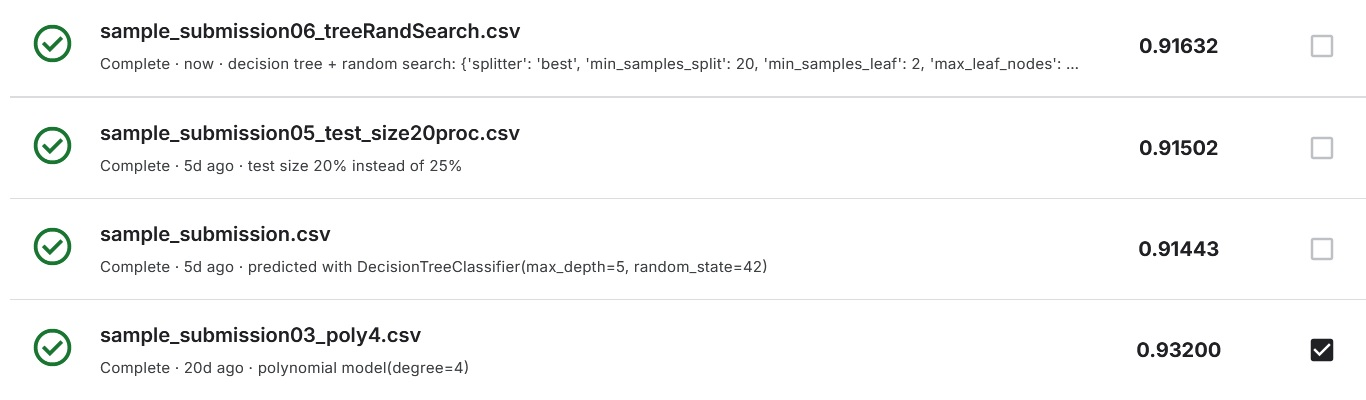